# Data Exploration - Credit Card Customers Churn Prediction

## Research Questions

### 1. Phân Bố Class và Mức Độ Imbalance
**Câu hỏi:** Tỷ lệ khách hàng churn so với không churn là bao nhiêu? Liệu có class imbalance nghiêm trọng cần xử lý?

### 2. Features Phân Biệt Churned vs Non-Churned Customers
**Câu hỏi:** Những features nào có sự khác biệt rõ rệt nhất giữa 2 nhóm khách hàng? Khách hàng churn có đặc điểm giao dịch (transaction patterns) và hành vi tài chính (financial behavior) như thế nào?

### 3. Multicollinearity và Feature Redundancy
**Câu hỏi:** Có features nào highly correlated với nhau không? Features tài chính như `Credit_Limit`, `Avg_Open_To_Buy`, `Total_Revolving_Bal` có mối quan hệ tuyến tính mạnh không?

### 4. Outliers và Extreme Values
**Câu hỏi:** Features nào chứa nhiều outliers? Outliers này là data errors hay legitimate extreme cases? Ảnh hưởng của outliers đến model performance?

### 5. Missing Patterns và Data Quality
**Câu hỏi:** Có missing values không? Nếu có, missing patterns có systematic không (MCAR, MAR, MNAR)? Categorical features có categories với very low frequency cần group lại không?

In [1]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

# Set random seed for reproducibility
np.random.seed(42)

In [2]:
# Add src to path
sys.path.append(os.path.abspath('..'))
from src.visualization import DataVisualizer
from src.data_processing import StatisticalAnalyzer

## 1. Load Data using NumPy

In [3]:
# Load data
data_path = '../data/raw/BankChurners.csv'

# Load headers
with open(data_path, 'r') as f:
    header_line = f.readline().strip()
    headers = np.array(header_line.replace('"', '').split(','))

# Load data as string first to handle mixed types
data = np.genfromtxt(
    data_path,
    delimiter=',',
    dtype=str,
    skip_header=1,
    encoding='utf-8'
)

# Remove quotes from string data
data = np.char.replace(data, '"', '')

print(f"Data shape: {data.shape}")
print(f"Number of features: {len(headers)}")
print(f"\nColumn names:")
for idx, col in enumerate(headers):
    print(f"{idx}: {col}")

Data shape: (10127, 23)
Number of features: 23

Column names:
0: CLIENTNUM
1: Attrition_Flag
2: Customer_Age
3: Gender
4: Dependent_count
5: Education_Level
6: Marital_Status
7: Income_Category
8: Card_Category
9: Months_on_book
10: Total_Relationship_Count
11: Months_Inactive_12_mon
12: Contacts_Count_12_mon
13: Credit_Limit
14: Total_Revolving_Bal
15: Avg_Open_To_Buy
16: Total_Amt_Chng_Q4_Q1
17: Total_Trans_Amt
18: Total_Trans_Ct
19: Total_Ct_Chng_Q4_Q1
20: Avg_Utilization_Ratio
21: Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1
22: Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2


## 2. Separate Numeric and Categorical Features

In [4]:
# Target: Attrition_Flag (index 1)
target_col = 1

# Numeric columns
numeric_cols = [2, 4, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
numeric_names = headers[numeric_cols]

# Categorical columns
categorical_cols = [3, 5, 6, 7, 8]
categorical_names = headers[categorical_cols]

# Extract data
y_raw = data[:, target_col]
X_numeric = data[:, numeric_cols].astype(np.float64)
X_categorical = data[:, categorical_cols]

print(f"Target variable shape: {y_raw.shape}")
print(f"Numeric features shape: {X_numeric.shape}")
print(f"Categorical features shape: {X_categorical.shape}")
print(f"\nNumeric features: {list(numeric_names)}")
print(f"\nCategorical features: {list(categorical_names)}")

Target variable shape: (10127,)
Numeric features shape: (10127, 14)
Categorical features shape: (10127, 5)

Numeric features: ['Customer_Age', 'Dependent_count', 'Months_on_book', 'Total_Relationship_Count', 'Months_Inactive_12_mon', 'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal', 'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio']

Categorical features: ['Gender', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category']


## 3. Analyze Target Variable Distribution

Target Variable Distribution:
Attrited Customer: 1627 (16.07%)
Existing Customer: 8500 (83.93%)


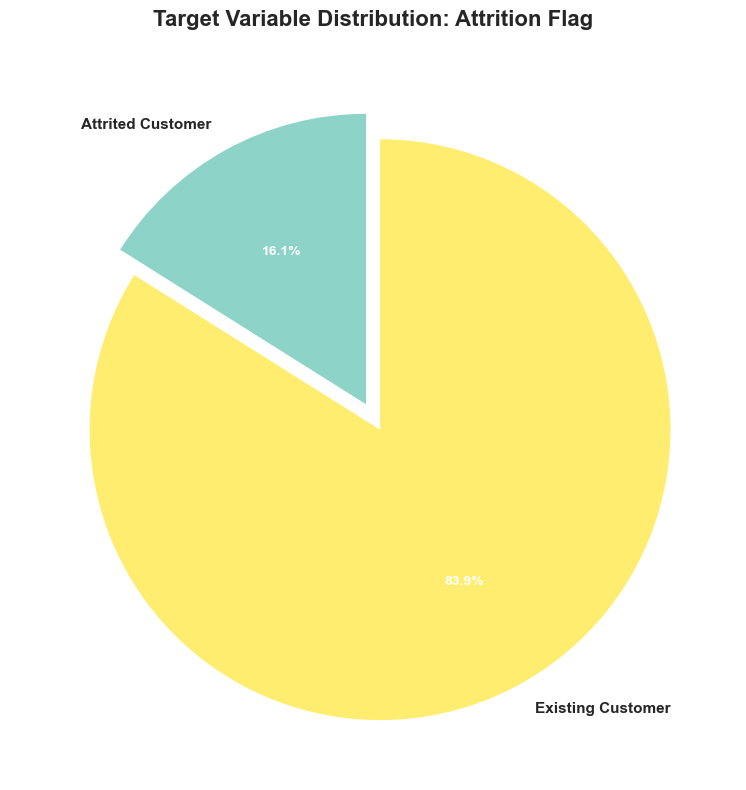

In [5]:
# Analyze target distribution
unique_targets, target_counts = np.unique(y_raw, return_counts=True)

print("Target Variable Distribution:")
for target, count in zip(unique_targets, target_counts):
    percentage = (count / len(y_raw)) * 100
    print(f"{target}: {count} ({percentage:.2f}%)")

# Visualize
visualizer = DataVisualizer()
fig = visualizer.plot_pie_chart(
    data=target_counts,
    labels=unique_targets,
    title="Target Variable Distribution: Attrition Flag"
)
plt.show()

- Tập dữ liệu có sự mất cân bằng rõ rệt

- Với bài toán **imbalanced classification** gây ảnh hưởng đến việc xây dựng mô hình và phải cần áp dụng các kỹ thuật xử lý imbalanced data như SMOTE, class weights, hoặc undersampling/oversampling.


## 4. Statistical Analysis of Numeric Features


In [6]:
# Compute statistics
analyzer = StatisticalAnalyzer()
stats = analyzer.compute_statistics(X_numeric)

stat_names = ['mean', 'median', 'std', 'var', 'min', 'max']

for feature_idx, feature_name in enumerate(numeric_names[:]):
    print(f"\n{feature_name}:")
    for stat_name in stat_names:
        value = stats[stat_name][feature_idx]
        print(f"  {stat_name:12s}: {value:12.4f}")


Customer_Age:
  mean        :      46.3260
  median      :      46.0000
  std         :       8.0164
  var         :      64.2630
  min         :      26.0000
  max         :      73.0000

Dependent_count:
  mean        :       2.3462
  median      :       2.0000
  std         :       1.2988
  var         :       1.6870
  min         :       0.0000
  max         :       5.0000

Months_on_book:
  mean        :      35.9284
  median      :      36.0000
  std         :       7.9860
  var         :      63.7765
  min         :      13.0000
  max         :      56.0000

Total_Relationship_Count:
  mean        :       3.8126
  median      :       4.0000
  std         :       1.5543
  var         :       2.4159
  min         :       1.0000
  max         :       6.0000

Months_Inactive_12_mon:
  mean        :       2.3412
  median      :       2.0000
  std         :       1.0106
  var         :       1.0213
  min         :       0.0000
  max         :       6.0000

Contacts_Count_12_mon:
  me

## 5. Visualize Feature Distributions

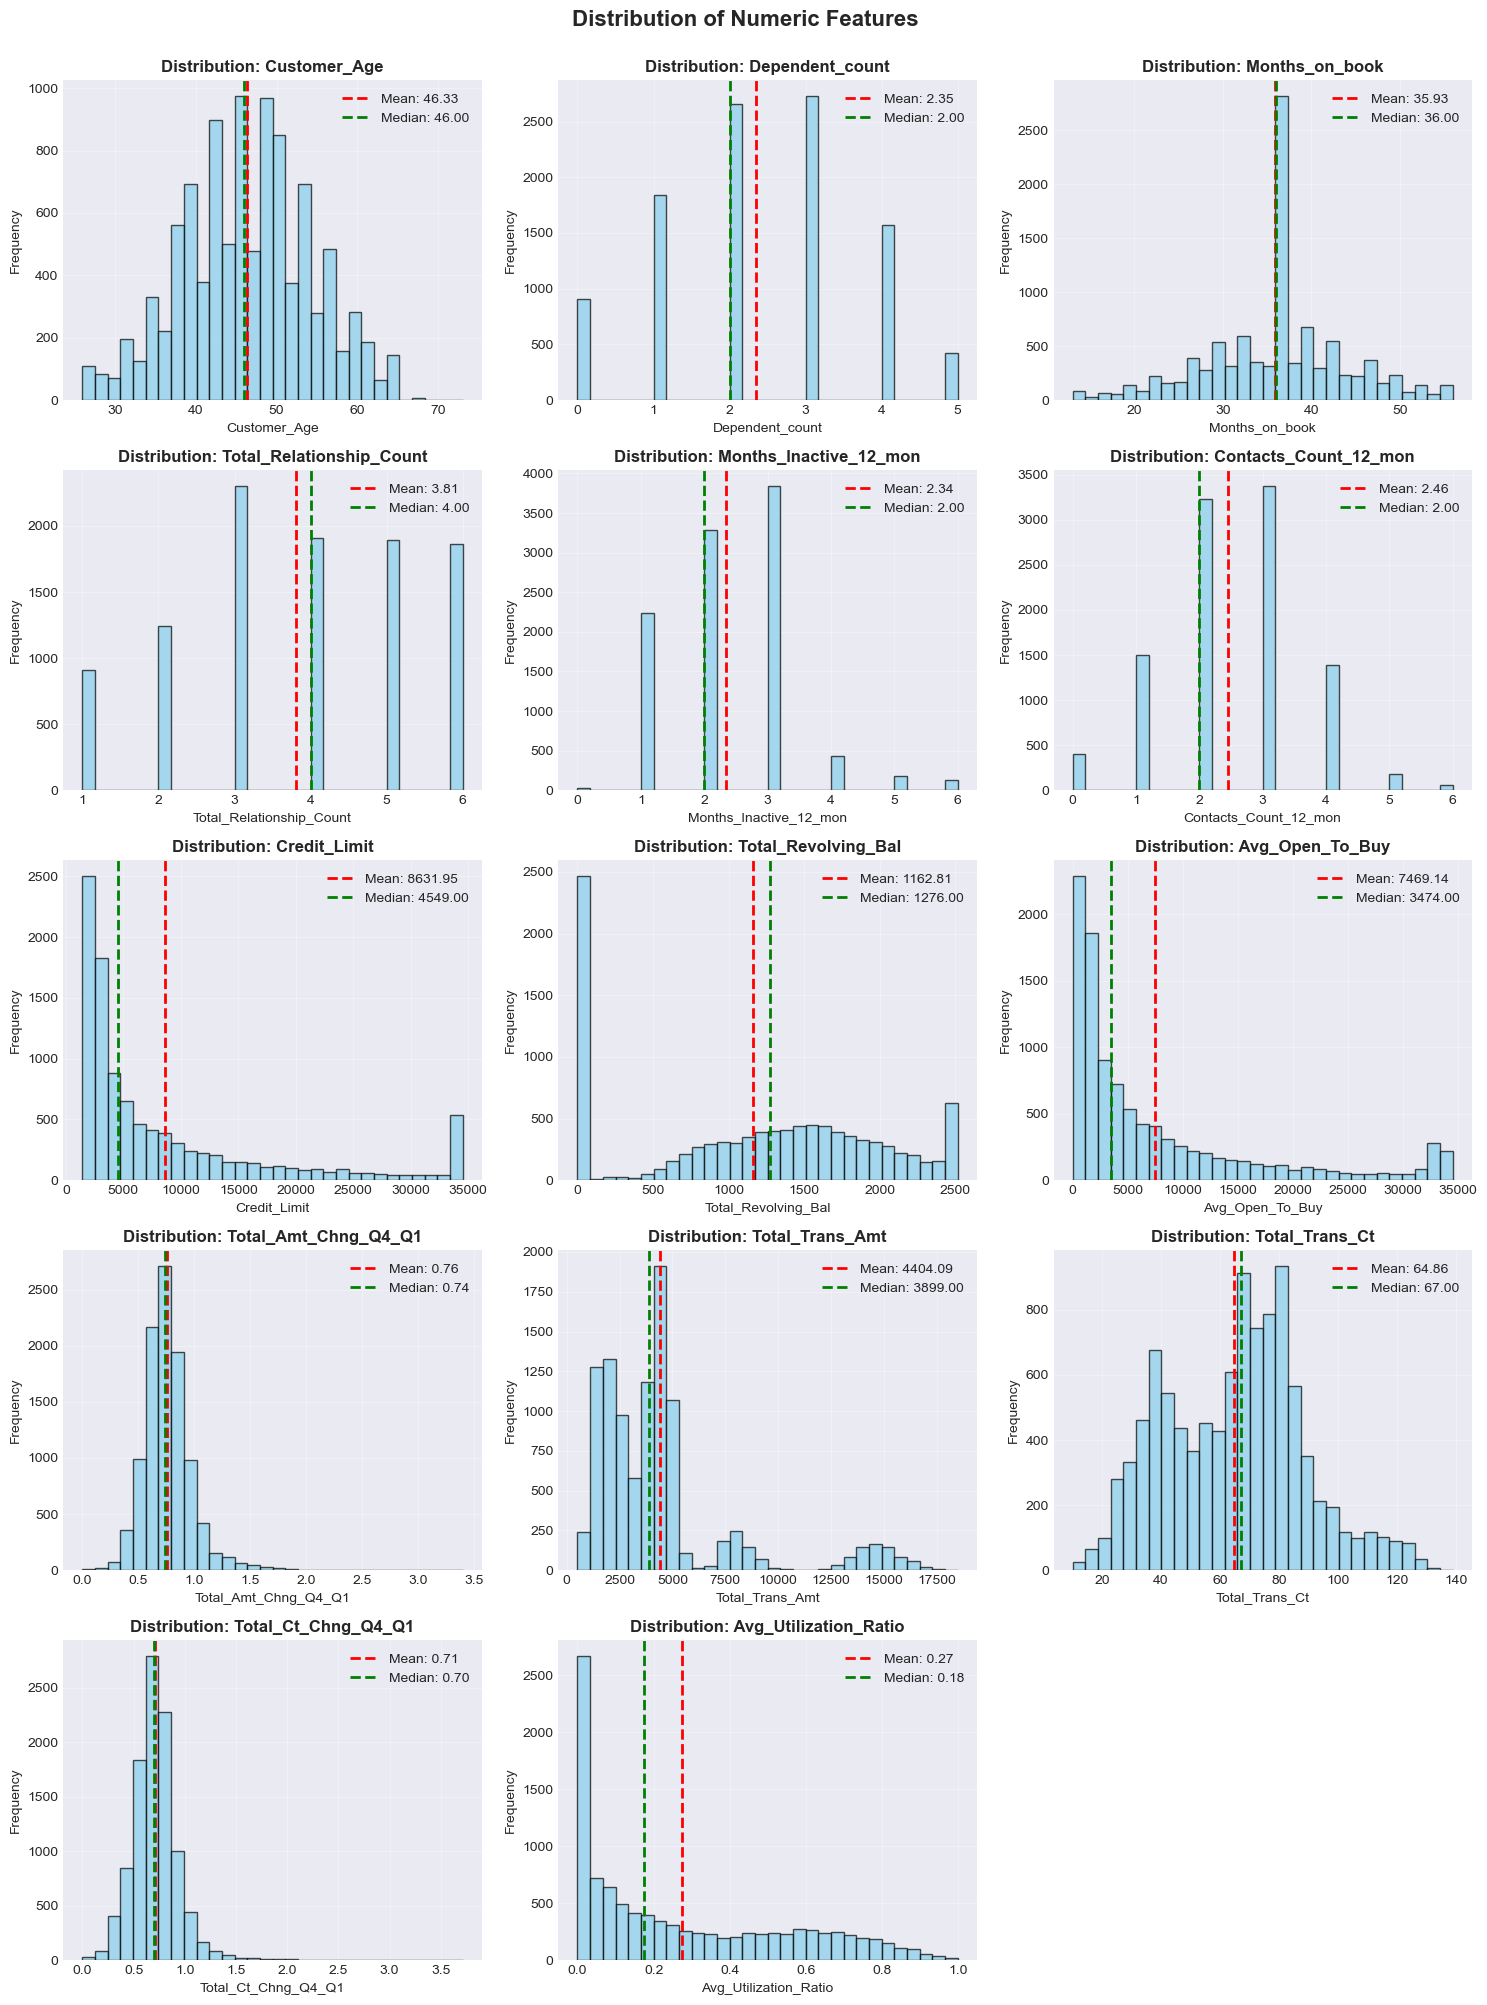

In [7]:
# Plot histograms for all numeric features
fig = visualizer.plot_histogram(
    data=X_numeric,
    feature_names=list(numeric_names),
    bins=30,
    title="Distribution of Numeric Features"
)
plt.show()

## 6. Correlation Analysis

Tính correlation matrix bằng:

$$\text{corr}(X, Y) = \frac{\text{cov}(X, Y)}{\sigma_X \cdot \sigma_Y}$$

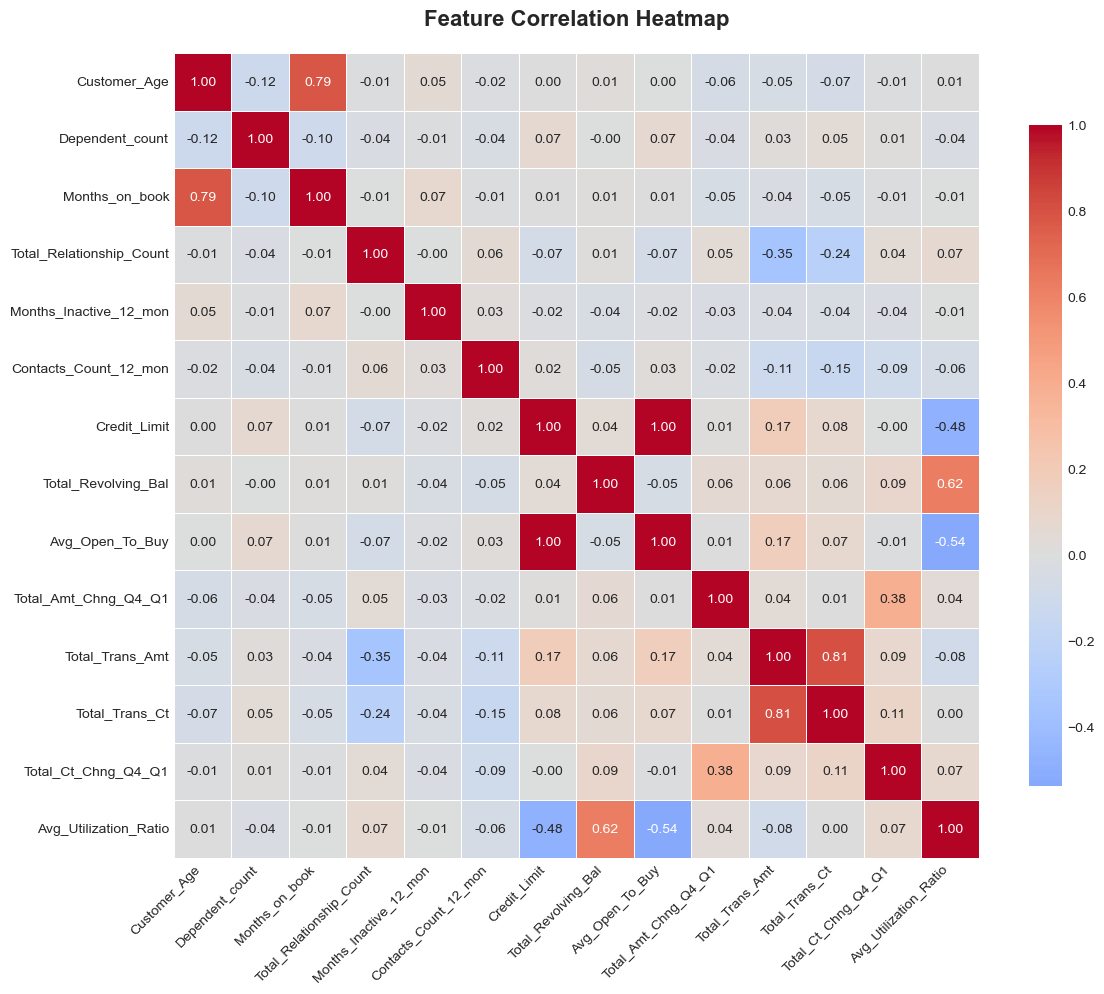

In [8]:
# Visualize correlation heatmap
fig = visualizer.plot_correlation_heatmap(
    data=X_numeric,
    feature_names=list(numeric_names),
    title="Feature Correlation Heatmap",
    cmap='coolwarm'
)
plt.show()

## 7. Categorical Cancellations Analysis

Phân tích hành vi của các biến phân loại trong tập dữ liệu, tập trung vào việc tìm hiểu các nhóm khách hàng nào có số lượng hủy thẻ tín dụng cao nhất.

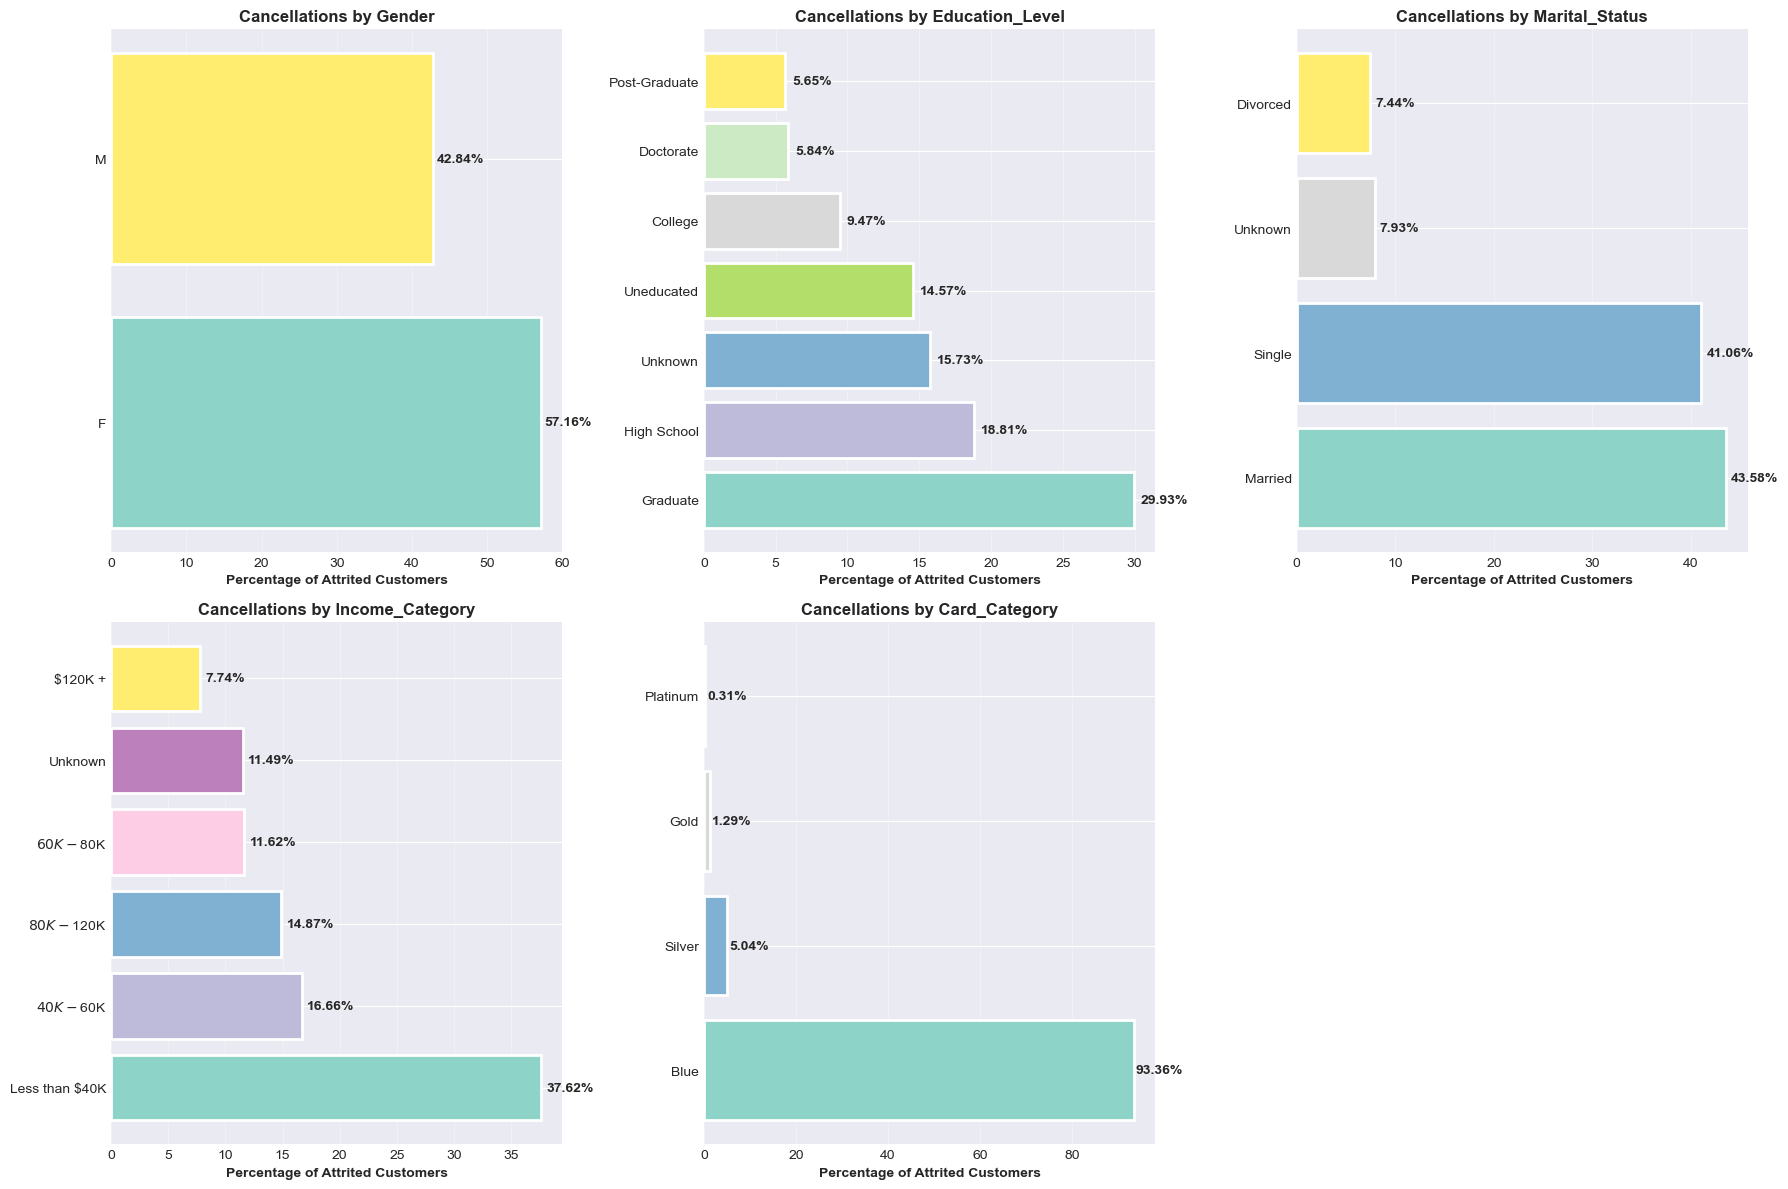


Top cancellation categories:
  Gender: F (57.16%)
  Education_Level: Graduate (29.93%)
  Marital_Status: Married (43.58%)
  Income_Category: Less than $40K (37.62%)
  Card_Category: Blue (93.36%)


In [9]:
# Filter only attrited customers
attrited_mask = (y_raw == 'Attrited Customer')
attrited_categorical = X_categorical[attrited_mask]

# Plot cancellations by categorical variables
fig = visualizer.plot_categorical_cancellations(
    categorical_data=attrited_categorical,
    feature_names=list(categorical_names),
    figsize=(18, 12)
)
plt.show()

# Print top categories
print("\nTop cancellation categories:")
for col_idx, cat_name in enumerate(categorical_names):
    unique_vals, counts = np.unique(attrited_categorical[:, col_idx], return_counts=True)
    sorted_idx = np.argsort(counts)[::-1]
    top_val = unique_vals[sorted_idx[0]]
    top_pct = (counts[sorted_idx[0]] / np.sum(counts)) * 100
    print(f"  {cat_name}: {top_val} ({top_pct:.2f}%)")

### Phân tích kết quả

Tỷ lệ hủy thẻ cao nhất:

**1. Gender:** Nữ > Nam 

**2. Education Level:** Graduate chiếm lớn nhất và không có sự khác biệt nhiều giữu các nhóm.

**3. Marital Status:** Tương đối cân bằng.

**4. Income Category:** Thu nhập càng cao thì tỷ lệ hủy thẻ càng thấp.

**5. Card Category:** Thẻ Blue chiếm áp đảo với **93.36%** số lượng hủy thẻ vì là loại thẻ phổ biến nhất nên tỷ lệ này là hợp lý.

-> Nhóm khách hàng (thu nhập dưới $40K) sử dụng thẻ Blue có xu hướng hủy thẻ nhiều hơn.


## 8. Transaction Behavior Analysis

Phân tích các biến định lượng, đặc biệt là các biến liên quan đến giao dịch. Các biến 'Total_Trans_Ct', 'Total_Revolving_Bal', 'Avg_Utilization_Ratio' và 'Total_Ct_Chng_Q4_Q1' đều có ảnh hưởng tích cực đến việc khách hàng ở lại hay rời bỏ dịch vụ.


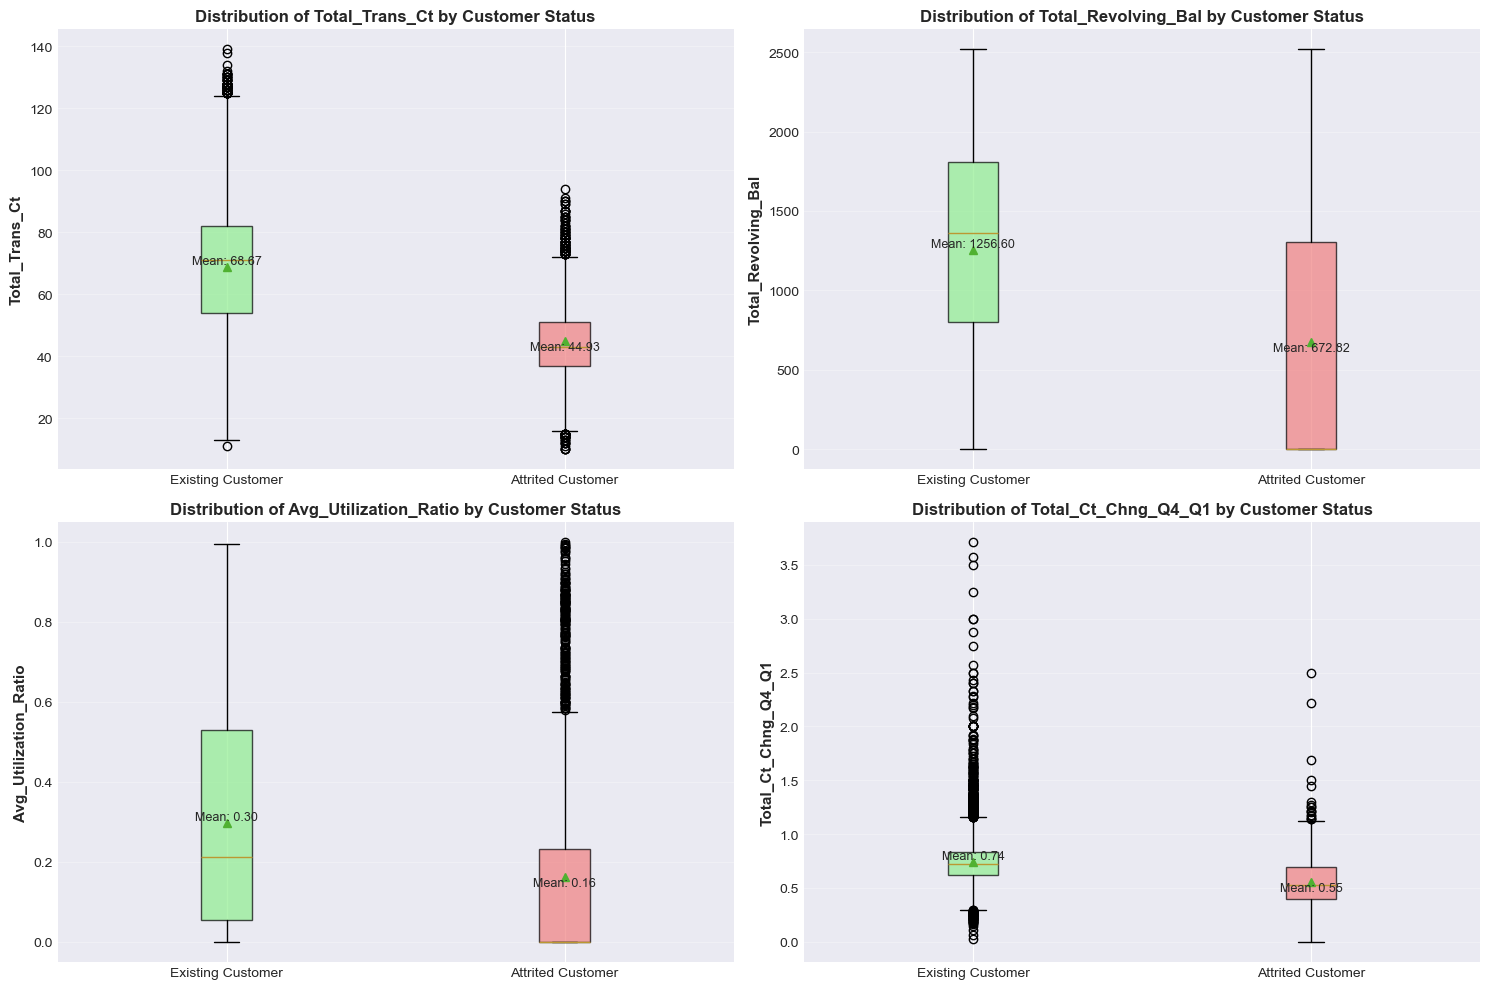


So sánh các biến giao dịch:

Total_Trans_Ct:
  Existing: Mean=68.67, Std=22.92
  Attrited: Mean=44.93, Std=14.56
  Chênh lệch: -34.57%

Total_Revolving_Bal:
  Existing: Mean=1256.60, Std=757.70
  Attrited: Mean=672.82, Std=921.10
  Chênh lệch: -46.46%

Avg_Utilization_Ratio:
  Existing: Mean=0.30, Std=0.27
  Attrited: Mean=0.16, Std=0.26
  Chênh lệch: -45.19%

Total_Ct_Chng_Q4_Q1:
  Existing: Mean=0.74, Std=0.23
  Attrited: Mean=0.55, Std=0.23
  Chênh lệch: -25.33%


In [10]:
# Select transaction variables
transaction_vars = ['Total_Trans_Ct', 'Total_Revolving_Bal', 'Avg_Utilization_Ratio', 'Total_Ct_Chng_Q4_Q1']
transaction_indices = [list(numeric_names).index(var) for var in transaction_vars]
transaction_data = X_numeric[:, transaction_indices]

# Split by customer status
existing_transaction = transaction_data[~attrited_mask]
attrited_transaction = transaction_data[attrited_mask]

# Plot comparison
fig = visualizer.plot_transaction_comparison(
    existing_data=existing_transaction,
    attrited_data=attrited_transaction,
    feature_names=transaction_vars
)
plt.show()

# Print statistics
print("\nSo sánh các biến giao dịch:")
for idx, var_name in enumerate(transaction_vars):
    mean_existing = np.mean(existing_transaction[:, idx])
    mean_attrited = np.mean(attrited_transaction[:, idx])
    diff_pct = ((mean_attrited - mean_existing) / mean_existing) * 100
    print(f"\n{var_name}:")
    print(f"  Existing: Mean={mean_existing:.2f}, Std={np.std(existing_transaction[:, idx]):.2f}")
    print(f"  Attrited: Mean={mean_attrited:.2f}, Std={np.std(attrited_transaction[:, idx]):.2f}")
    print(f"  Chênh lệch: {diff_pct:.2f}%")


### Phân tích kết quả

**1. Total_Trans_Ct (Số lượng giao dịch):**: Khách hàng rời bỏ có ít giao dịch hơn đáng kể

**2. Total_Revolving_Bal (Số dư xoay vòng):**: Khách hàng rời bỏ có số dư thấp hơn gần một nửa

**3. Avg_Utilization_Ratio (Tỷ lệ sử dụng thẻ trung bình):**: Khàng rời bỏ sử dụng thẻ ít hơn rất nhiều

**4. Total_Ct_Chng_Q4_Q1 (Thay đổi số giao dịch Q4/Q1):**: Khách hàng rời bỏ có xu hướng giảm giao dịch theo thời gian

-> Các feature giao dịch đều cho thấy khách hàng rời bỏ có **mức độ tương tác thấp hơn rất nhiều** với dịch vụ

## 9. Transaction Count Distribution

Phân tích phân phối số lượng giao dịch trong 12 tháng qua theo từng nhóm khách hàng để hiểu rõ hơn về hành vi giao dịch của họ.


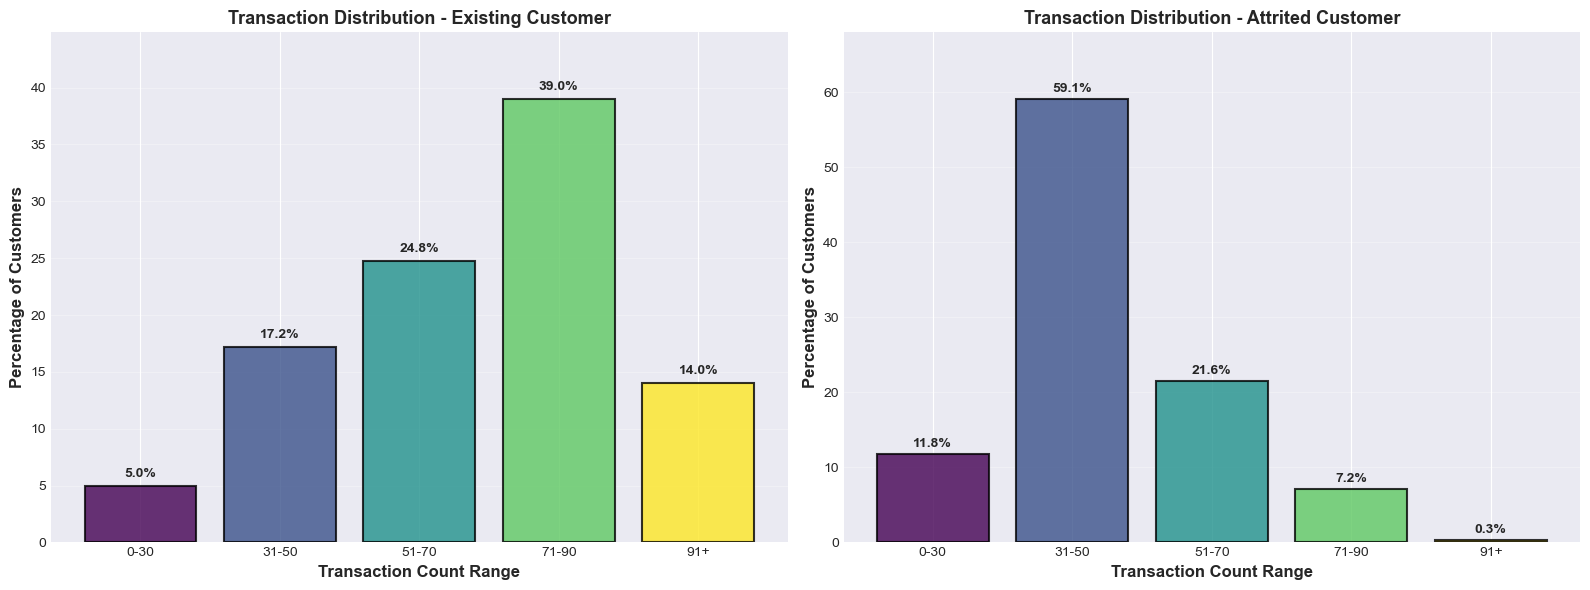

In [11]:
# Get Total_Trans_Ct data
trans_ct_idx = list(numeric_names).index('Total_Trans_Ct')
trans_ct_data = X_numeric[:, trans_ct_idx]

# Define bins
bins = [0, 30, 50, 70, 90, 150]
bin_labels = ['0-30', '31-50', '51-70', '71-90', '91+']

# Plot distribution bins
fig = visualizer.plot_transaction_distribution_bins(
    trans_ct_data=trans_ct_data,
    attrited_mask=attrited_mask,
    bins=bins,
    bin_labels=bin_labels
)
plt.show()


### Phân tích kết quả

**Existing Customers:**
- Phân phối tương đối đều, tập trung ở nhóm **71-90 giao dịch (39%)**
- Có tỷ lệ cao ở nhóm 91+ giao dịch (14%)
- Chỉ 4.96% có số giao dịch rất thấp (0-30)

**Attrited Customers:**
- Tập trung mạnh ở nhóm **31-50 giao dịch (59%)**
- Có 11.80% ở nhóm giao dịch rất thấp (0-30)
- Gần như không có ai ở nhóm 91+ giao dịch (chỉ 0.3%)

-> Khách hàng có **ít hơn 50 giao dịch/năm** có nguy cơ rời bỏ rất cao (chiếm 70.9% khách hàng attrited)

-> Khách hàng có **nhiều hơn 70 giao dịch/năm** có xu hướng trung thành cao (chiếm 53% khách hàng existing)

## 10. Transaction Count vs Amount Analysis

Phân tích mối quan hệ giữa số lượng giao dịch và tổng giá trị giao dịch trong 12 tháng qua để xem có mô hình nào phân biệt rõ ràng giữa hai nhóm khách hàng.


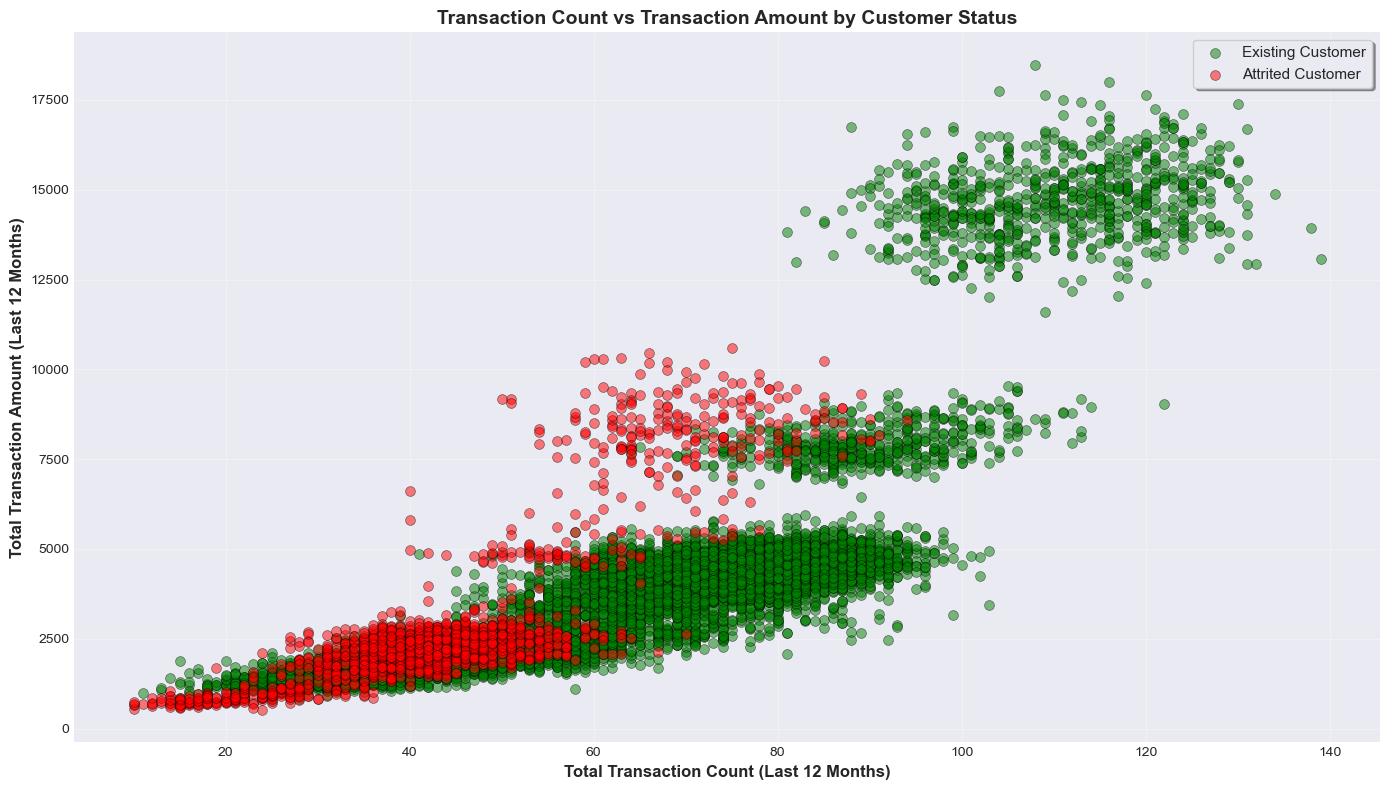


Tương quan (Total_Trans_Ct vs Total_Trans_Amt):
  Existing Customers: 0.8125
  Attrited Customers: 0.8272


In [12]:
# Get transaction data
trans_amt_idx = list(numeric_names).index('Total_Trans_Amt')
trans_amt_data = X_numeric[:, trans_amt_idx]

# Plot scatter
fig = visualizer.plot_transaction_scatter(
    trans_ct_data=trans_ct_data,
    trans_amt_data=trans_amt_data,
    attrited_mask=attrited_mask
)
plt.show()

# Print correlation
corr_existing = np.corrcoef(trans_ct_data[~attrited_mask], trans_amt_data[~attrited_mask])[0, 1]
corr_attrited = np.corrcoef(trans_ct_data[attrited_mask], trans_amt_data[attrited_mask])[0, 1]
print(f"\nTương quan (Total_Trans_Ct vs Total_Trans_Amt):")
print(f"  Existing Customers: {corr_existing:.4f}")
print(f"  Attrited Customers: {corr_attrited:.4f}")


### Phân tích kết quả

**Mối tương quan mạnh:**: Cả hai nhóm đều có correlation cao tương tự nhau
- **Nhóm Attrited:** Tập trung ở góc dưới bên trái
  - Số giao dịch: 20-60 giao dịch
  - Giá trị giao dịch: $0-5,000

- **Nhóm Existing:** Phân tán rộng hơn
  - Số giao dịch: 40-140 giao dịch
  - Giá trị giao dịch: $2,000-18,000
  - Các cụm (3 cụm) phân tách theo mức độ hoạt động

-> Có một **vùng phân tách rõ ràng**: khách hàng với < 60 giao dịch VÀ < $5,000 

## 11. Categorical Features Comparison

So sánh phân phối các đặc tính phân loại giữa hai nhóm khách hàng để tìm ra những đặc điểm phân biệt quan trọng.


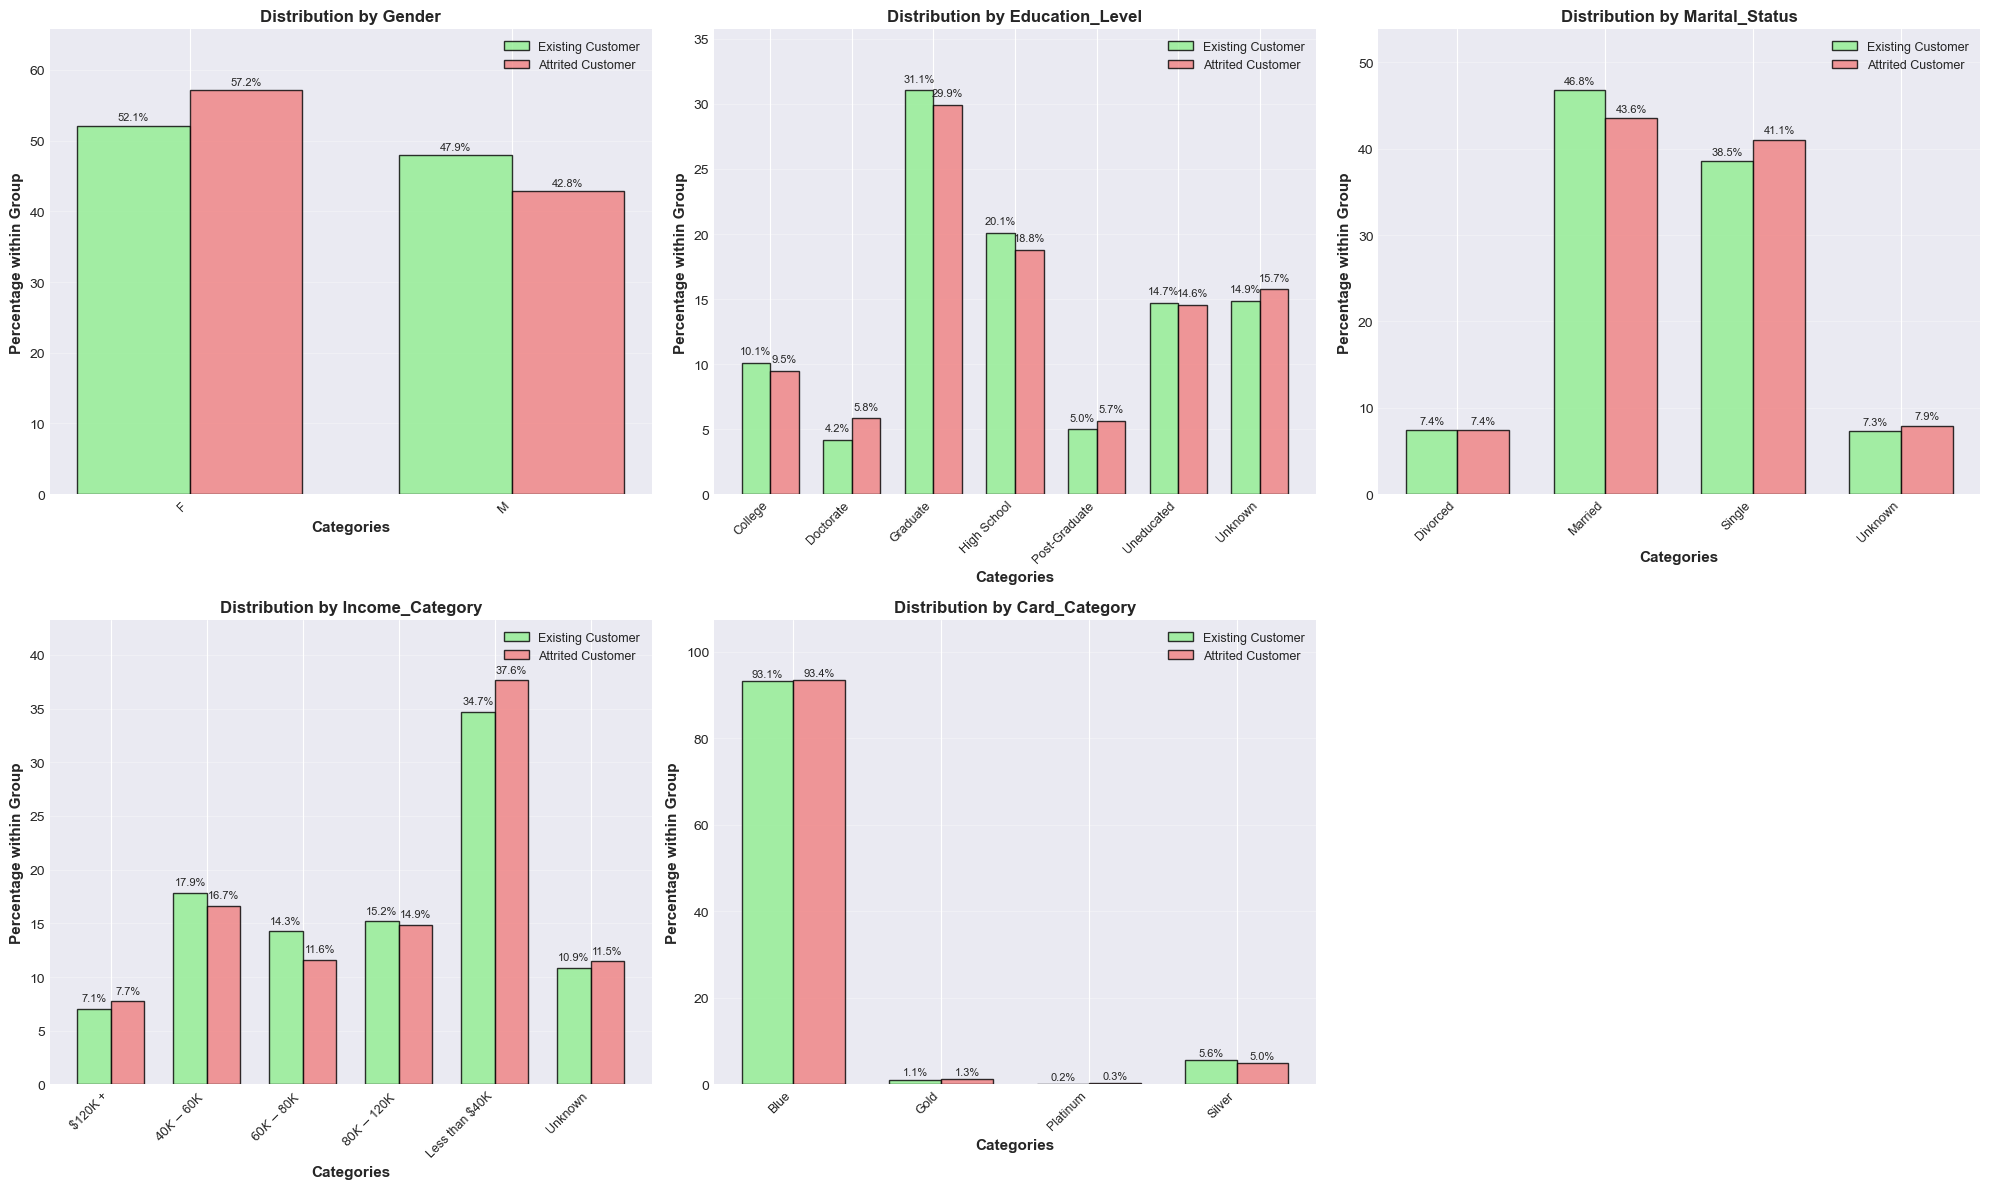

In [13]:
# Plot categorical comparison
fig = visualizer.plot_categorical_comparison(
    categorical_data=X_categorical,
    attrited_mask=attrited_mask,
    feature_names=list(categorical_names)
)
plt.show()


### Phân tích kết quả

- Các features (giới tính, học vấn, hôn nhân, loại thẻ) có **sức phân biệt rất yếu**
- Chỉ có **Income_Category** cho thấy sự khác biệt nhất định
- **Transaction features** có ý nghĩa phân biệt hơn các đặc tính nhân khẩu học
-> Ưu tiên **behavioral features** hơn là demographic features
